# CECS 427 - Assignment 2

## Resources (Required Reading)

* Lecture Slides: Strong and Weak Ties

* NetworkX Clustering: https://networkx.org/documentation/stable/reference/algorithms/clustering.html

* NetworkX Community: https://networkx.org/documentation/stable/reference/algorithms/community.html

* NetworkX Bridges: https://networkx.org/documentation/stable/reference/algorithms/bridges.html

---

## Part A – Triadic Closure & Clustering Coefficient on the Karate Club Graph

You will continue working with the Zachary Karate Club friendship network.

### **Using NetworkX**

1. **Clustering Coefficient:**

    * Compute and display the local clustering coefficient for every node using `nx.clustering()`

    * Identify the node(s) with the highest and lowest clustering coefficients

    * Compute the average clustering coefficient of the graph

2. **Triadic Closure:**

    * Count the total number of triangles in the graph using `nx.triangles()`

    * For node `0`, list all triangles it participates in (i.e., find all pairs of node 0's neighbors that are also connected to each other)

3. **Neighborhood Overlap:**

    * Implement a function `neighborhood_overlap(G, u, v)` that computes the neighborhood overlap of edge (u, v)

    * Compute and display the neighborhood overlap for edges `(0, 1)`, `(0, 31)`, and `(2, 33)`

    * Identify the edge with the lowest non-zero neighborhood overlap (this is the closest to a local bridge)



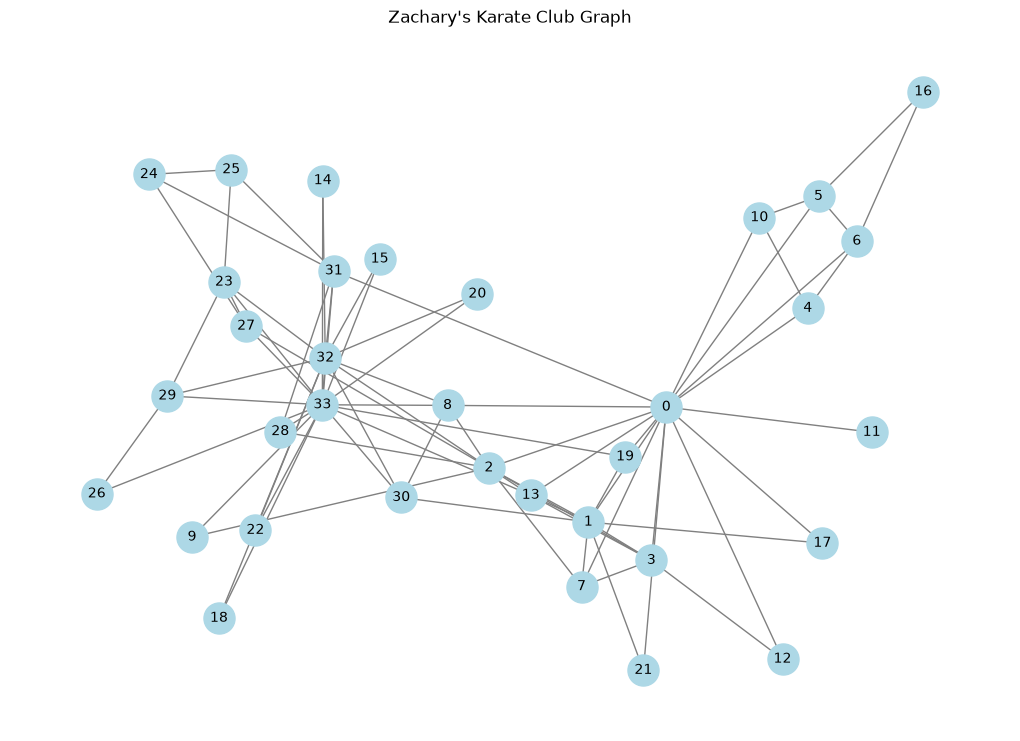

In [1]:
# Load and Draw the Karate Club Graph
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import deque

G = nx.karate_club_graph()

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=126)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=500, font_size=10, edge_color='gray')
plt.title("Zachary's Karate Club Graph")
plt.show()


In [2]:
# A1 - Clustering Coefficient

# Compute the clustering coefficient for all nodes in graph G
# Round the value to 2 decimals
clustering_all_nodes = {node: round(value, 2) for node,value in nx.clustering(G).items()}

# Display the clustering for each node
print(clustering_all_nodes)

# Find nodes with min and max clustering value
min_val = min(clustering_all_nodes.values())
max_val = max(clustering_all_nodes.values())
min_nodes = [node for node, val in clustering_all_nodes.items() if val == min_val]
max_nodes = [node for node, val in clustering_all_nodes.items() if val == max_val]

# Display the found min and max nodes
print(f"Min value: {min_val}")
print(f"Nodes with min clustering values: {min_nodes}")
print(f"Max value: {max_val}")
print(f"Nodes with max clustering values: {max_nodes}")

# Calculate and display average
avg = round(nx.average_clustering(G), 2)
print(f"Average clustering coefficient of the graph: {avg}")

{0: 0.15, 1: 0.33, 2: 0.24, 3: 0.67, 4: 0.67, 5: 0.5, 6: 0.5, 7: 1.0, 8: 0.5, 9: 0, 10: 0.67, 11: 0, 12: 1.0, 13: 0.6, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.0, 19: 0.33, 20: 1.0, 21: 1.0, 22: 1.0, 23: 0.4, 24: 0.33, 25: 0.33, 26: 1.0, 27: 0.17, 28: 0.33, 29: 0.67, 30: 0.5, 31: 0.2, 32: 0.2, 33: 0.11}
Min value: 0
Nodes with min clustering values: [9, 11]
Max value: 1.0
Nodes with max clustering values: [7, 12, 14, 15, 16, 17, 18, 20, 21, 22, 26]
Average clustering coefficient of the graph: 0.57


In [3]:
# A2 - Triadic Closure: Triangles
nodes = list(G.nodes())
total_triangles = 0

# Count total number of triangles in the graph
for node in nodes:
  total_triangles += nx.triangles(G, nodes=node)

total_triangles = total_triangles // 3 # divide by 3 to avoid triple counting
print(f"Total number of triangles in the graph: {total_triangles}")

import itertools # used to generate combination of 2 nodes

# List of neighbors nodes of node 0
neighbors_of_node_0 = list(G.neighbors(0))

# Check each pair of nodes in the neighbor list to see if they have an edge
connected_neighbor_pairs = []
for n1,n2 in itertools.combinations(neighbors_of_node_0, 2):
  if G.has_edge(n1, n2):
    connected_neighbor_pairs.append((n1,n2))

print(f"Neighbors of {0} that are connected to each other:")
print(connected_neighbor_pairs)


Total number of triangles in the graph: 45
Neighbors of 0 that are connected to each other:
[(1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (2, 3), (2, 7), (2, 8), (2, 13), (3, 7), (3, 12), (3, 13), (4, 6), (4, 10), (5, 6), (5, 10)]


In [4]:
# A3 - Neighborhood Overlap

# Implement function to compute the neighborhood overlap of the edge (u, v)
def compute_neighborhood_overlap(G, u, v) -> float:
    # Store the neighbors of each node
    neighbors_of_u = set(G.neighbors(u))
    neighbors_of_v = set(G.neighbors(v))

    # Get common neighbors and total surrounding neighbors
    common_neighbors = neighbors_of_u & neighbors_of_v
    total_neighbors = (neighbors_of_u | neighbors_of_v) - {u, v}

    # Avoid division by zero
    if len(total_neighbors) == 0:
        return 0

    return len(common_neighbors) / len(total_neighbors)


# Compute and display the neighborhood overlap for edges (0, 1), (0, 31), and (2, 33)
neighborhood_overlap_0_1 = compute_neighborhood_overlap(G, 0, 1)
neighborhood_overlap_0_31 = compute_neighborhood_overlap(G, 0, 31)
neighborhood_overlap_2_33 = compute_neighborhood_overlap(G, 2, 33)

print("Neighborhood overlap values for the edges:")
print(f"(0, 1): {neighborhood_overlap_0_1:.2f}")
print(f"(0, 31): {neighborhood_overlap_0_31:.2f}")
print(f"(2, 33): {neighborhood_overlap_2_33:.2f}")


# Identify the edge with the lowest non-zero neighborhood overlap
# (closest to a local bridge)
lowest_overlap = float('inf')
lowest_overlap_u = -1
lowest_overlap_v = -1

# Loop through all edges (u, v)
for u, v in G.edges():
    current_overlap = compute_neighborhood_overlap(G, u, v)

    if current_overlap < lowest_overlap and current_overlap > 0:
        lowest_overlap = current_overlap
        lowest_overlap_u = u
        lowest_overlap_v = v

print(
    f"The edge with lowest non-zero neighborhood overlap is "
    f"({lowest_overlap_u}, {lowest_overlap_v}): {lowest_overlap:.2f}"
)

Neighborhood overlap values for the edges:
(0, 1): 0.44
(0, 31): 0.00
(2, 33): 0.29
The edge with lowest non-zero neighborhood overlap is (2, 32): 0.05


---

## Part B – Bridges, Local Bridges & Strong/Weak Tie Analysis

### **Using NetworkX and your own implementations**

1. **Bridges:**

    * Use `nx.bridges()` to find all bridges in the Karate Club Graph

    * Draw the graph highlighting any bridges in red

2. **Local Bridges (from scratch):**

    * Implement a function `find_local_bridges(G)` that returns all local bridges and their spans

    * A local bridge is an edge whose removal increases the distance between its endpoints to strictly > 2 (equivalently, its endpoints share no common neighbors)

    * The span of a local bridge is the shortest path distance between u and v after removing the edge (u, v).

    * Display all local bridges and their spans

3. **Strong/Weak Tie Labeling:**

    * Label edges as **strong** or **weak** based on neighborhood overlap: if overlap >= median overlap, label as strong; otherwise weak

    * Draw the graph with strong ties as thick solid lines and weak ties as thin dashed lines



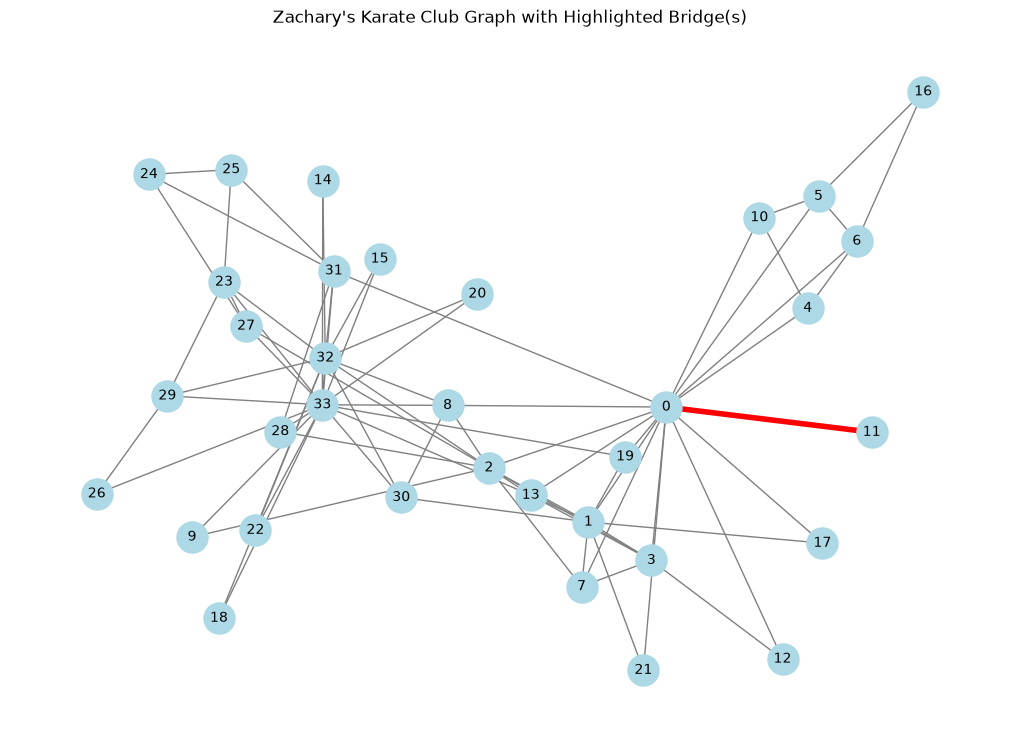

In [48]:
# B1 - Bridges
# Saving the bridge(s) in the graph
bridges = list(nx.bridges(G))

# Draw graph highlighting the bridges
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=126)
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=500, font_size=10, edge_color='gray', )

# Overlay just the highlighted edge on top
nx.draw_networkx_edges(
    G, 
    pos, 
    edgelist=bridges, 
    edge_color='red', 
    width=4.0
)

plt.title("Zachary's Karate Club Graph with Highlighted Bridge(s)")
plt.show()


In [49]:
# B2 - Local Bridges (from scratch)

# YOUR CODE HERE


In [50]:
# B3 - Strong/Weak Tie Labeling based on Neighborhood Overlap

# YOUR CODE HERE


---

## Part C – Girvan-Newman Divisive Method

Implement the **Girvan-Newman divisive method** from scratch to detect communities in the Karate Club Graph.

### **Requirements**

1. **Implement BFS-based edge betweenness computation:**

    * For each node u, perform a BFS from u

    * Count the number of shortest paths from u to every other node

    * Working bottom-up from the BFS tree, compute the flow contribution of each edge

    * Sum contributions from all source nodes, then divide by 2 (each pair is counted twice)

2. **Implement the Girvan-Newman algorithm:**

    * Repeatedly: compute edge betweenness → remove edge(s) with highest betweenness → check number of components

    * Stop when the graph splits into **2 communities**

3. **Visualize and compare:**

    * Draw the graph colored by detected communities

    * Compare your result with NetworkX's built-in `girvan_newman`


In [51]:
# C1 - BFS-based Edge Betweenness Computation (from scratch)

# YOUR CODE HERE


In [52]:
# C2 - Girvan-Newman Algorithm (from scratch)

# YOUR CODE HERE


In [53]:
# C3 - Visualize detected communities

# YOUR CODE HERE


In [54]:
# Compare with NetworkX's Girvan-Newman

# YOUR CODE HERE
